<a href="https://colab.research.google.com/github/hadriman11/ACE6313-Food-Waste-SDG12/blob/main/notebooks/Part_B_ML_Models.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Part B — Machine Learning Models
## ACE6313 Machine Learning — Food Waste (SDG 12)

**Author:** Student 2 (Machine Learning Models)

Run Part A first to generate `clean_food_waste.csv`. This notebook trains 6 algorithms,
tunes hyperparameters, and compares performance.


## 1. Imports & Load Clean Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix, ConfusionMatrixDisplay)
from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv("/content/drive/My Drive/clean_food_waste.csv")
print("Shape:", df.shape)
df.head()

Mounted at /content/drive
Shape: (214, 9)


,combined figures (kg/capita/year),Household estimate (kg/capita/year),Retail estimate (kg/capita/year),Food service estimate (kg/capita/year),household_ratio,retail_ratio,foodservice_ratio,Region_encoded,Confidence_encoded
0,-0.035936,-0.125577,0.153480,0.094995,-0.188037,0.270371,0.073524,12,0
1,0.009301,-0.070845,0.153480,0.094995,-0.141933,0.235596,0.036132,13,0
2,0.371193,0.367011,0.153480,0.094995,0.202311,-0.024053,-0.243065,7,0
3,-0.171645,-0.016113,-0.367865,-0.213020,0.350747,-0.470177,-0.158126,13,1
4,0.778321,0.859598,0.153480,0.094995,0.543865,-0.281674,-0.520080,14,0


## 2. Train/Test Split

In [2]:
X = df.drop(columns=["Confidence_encoded"])
y = df["Confidence_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("Class distribution in y:")
print(y.value_counts().sort_index())

Train: (171, 8)  Test: (43, 8)
Class distribution in y:
Confidence_encoded
0    130
1     61
2     13
3     10
Name: count, dtype: int64


## 3. Train 6 Models

In [3]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree":       DecisionTreeClassifier(random_state=42),
    "Random Forest":       RandomForestClassifier(random_state=42),
    "SVM":                 SVC(),
    "kNN":                 KNeighborsClassifier(),
    "Gradient Boosting":   GradientBoostingClassifier(random_state=42),
}

baseline = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    baseline[name] = {
        "Accuracy":  accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, average="weighted", zero_division=0),
        "Recall":    recall_score(y_test, pred, average="weighted", zero_division=0),
        "F1":        f1_score(y_test, pred, average="weighted", zero_division=0),
    }

baseline_df = pd.DataFrame(baseline).T.round(3)
print("Baseline performance (before tuning):")
baseline_df

Baseline performance (before tuning):


,Accuracy,Precision,Recall,F1
Logistic Regression,0.860,0.781,0.860,0.818
Decision Tree,0.977,0.984,0.977,0.977
Random Forest,0.907,0.863,0.907,0.884
SVM,0.605,0.383,0.605,0.469
kNN,0.791,0.700,0.791,0.736
Gradient Boosting,0.953,0.953,0.953,0.953


## 4. Hyperparameter Tuning
Tune 3 models with GridSearchCV to show improvement.

In [4]:
# --- Tune Random Forest ---
rf_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 5, 10, 20],
    "min_samples_split": [2, 5, 10],
}
rf_search = GridSearchCV(RandomForestClassifier(random_state=42),
                         rf_grid, cv=5, scoring="f1_weighted", n_jobs=-1)
rf_search.fit(X_train, y_train)
print("RF best params:", rf_search.best_params_)
print("RF best CV F1:", round(rf_search.best_score_, 3))

RF best params: {'max_depth': None, 'min_samples_split': 10, 'n_estimators': 100}
RF best CV F1: 0.902


In [5]:
# --- Tune SVM ---
svm_grid = {
    "C": [0.1, 1, 10, 100],
    "kernel": ["linear", "rbf"],
    "gamma": ["scale", "auto"],
}
svm_search = GridSearchCV(SVC(), svm_grid, cv=5, scoring="f1_weighted", n_jobs=-1)
svm_search.fit(X_train, y_train)
print("SVM best params:", svm_search.best_params_)
print("SVM best CV F1:", round(svm_search.best_score_, 3))

SVM best params: {'C': 100, 'gamma': 'scale', 'kernel': 'linear'}
SVM best CV F1: 0.898


In [6]:
# --- Tune kNN ---
knn_grid = {
    "n_neighbors": [3, 5, 7, 9, 11],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"],
}
knn_search = GridSearchCV(KNeighborsClassifier(), knn_grid, cv=5,
                          scoring="f1_weighted", n_jobs=-1)
knn_search.fit(X_train, y_train)
print("kNN best params:", knn_search.best_params_)
print("kNN best CV F1:", round(knn_search.best_score_, 3))

kNN best params: {'metric': 'manhattan', 'n_neighbors': 3, 'weights': 'distance'}
kNN best CV F1: 0.844


## 5. Evaluate Tuned Models

In [7]:
tuned_models = {
    "Random Forest (tuned)": rf_search.best_estimator_,
    "SVM (tuned)":           svm_search.best_estimator_,
    "kNN (tuned)":           knn_search.best_estimator_,
}

tuned = {}
for name, model in tuned_models.items():
    pred = model.predict(X_test)
    tuned[name] = {
        "Accuracy":  accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, average="weighted", zero_division=0),
        "Recall":    recall_score(y_test, pred, average="weighted", zero_division=0),
        "F1":        f1_score(y_test, pred, average="weighted", zero_division=0),
    }

tuned_df = pd.DataFrame(tuned).T.round(3)
print("Tuned performance:")
tuned_df

Tuned performance:


,Accuracy,Precision,Recall,F1
Random Forest (tuned),0.884,0.841,0.884,0.861
SVM (tuned),0.884,0.834,0.884,0.857
kNN (tuned),0.860,0.802,0.860,0.829


In [8]:
# Detailed report for the best model
best_name = tuned_df["F1"].idxmax()
best_model = tuned_models[best_name]
pred = best_model.predict(X_test)
print(f"Best model: {best_name}\n")
print(classification_report(y_test, pred, zero_division=0))

Best model: Random Forest (tuned)

              precision    recall  f1-score   support

           0       0.93      1.00      0.96        26
           1       1.00      1.00      1.00        12
           2       0.00      0.00      0.00         3
           3       0.00      0.00      0.00         2

    accuracy                           0.88        43
   macro avg       0.48      0.50      0.49        43
weighted avg       0.84      0.88      0.86        43



## 6. Compare All Models

In [9]:
# Combine baseline + tuned into one comparison table
all_results = pd.concat([baseline_df, tuned_df]).round(3)
print(all_results)
all_results.to_csv("/content/drive/My Drive/model_results.csv")

                       Accuracy  Precision  Recall     F1
Logistic Regression       0.860      0.781   0.860  0.818
Decision Tree             0.977      0.984   0.977  0.977
Random Forest             0.907      0.863   0.907  0.884
SVM                       0.605      0.383   0.605  0.469
kNN                       0.791      0.700   0.791  0.736
Gradient Boosting         0.953      0.953   0.953  0.953
Random Forest (tuned)     0.884      0.841   0.884  0.861
SVM (tuned)               0.884      0.834   0.884  0.857
kNN (tuned)               0.860      0.802   0.860  0.829


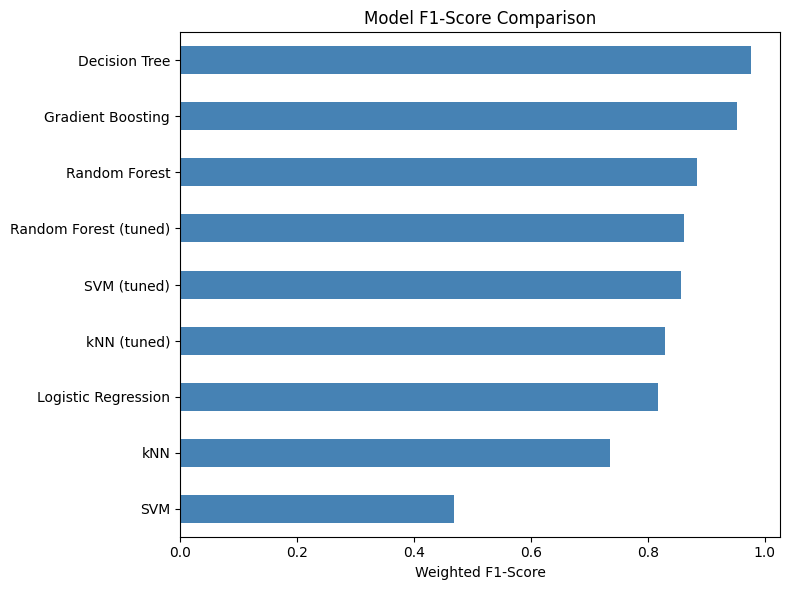

In [10]:
# Bar chart of F1-scores
all_results["F1"].sort_values().plot(kind="barh", figsize=(8,6), color="steelblue")
plt.title("Model F1-Score Comparison")
plt.xlabel("Weighted F1-Score")
plt.tight_layout()
plt.savefig("/content/drive/My Drive/model_comparison.png", dpi=150)
plt.show()

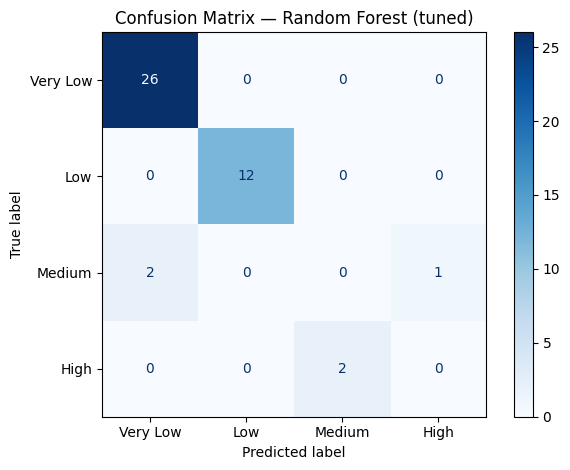

In [11]:
# Confusion matrix for the best model
cm = confusion_matrix(y_test, pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Very Low","Low","Medium","High"])
disp.plot(cmap="Blues")
plt.title(f"Confusion Matrix — {best_name}")
plt.tight_layout()
plt.savefig("/content/drive/My Drive/confusion_matrix.png", dpi=150)
plt.show()